In [3]:
import pandas as pd

# Load utility data
utility_df = pd.read_csv("utility.csv")

# Load allocation data
gpu = pd.read_csv("GPU.csv")
api = pd.read_csv("API_X.csv")
task = pd.read_csv("Task_A.csv")

# Combine allocation data
alloc_df = pd.concat([gpu, api, task], ignore_index=True)

# Merge on Agent ID
df = pd.merge(utility_df, alloc_df, on="Agent")

print(df.head())

   Unnamed: 0_x Agent Target  Urgency   Utility   Timestamp  Unnamed: 0_y  \
0             0    A1    GPU        4  4.842763  1774599335             0   
1             1    A2    GPU        1  5.786918  1774599335             1   
2             2    A3    GPU        4  2.433758  1774599335             2   
3             3    A4    GPU        3  4.835644  1774599335             3   
4             4    A5    GPU        2  5.561697  1774599335             4   

   Allocated  Percentage (%)  
0   2.110449            2.11  
1   2.380162            2.38  
2   1.469624            1.47  
3   3.412024            3.41  
4   0.803787            0.80  


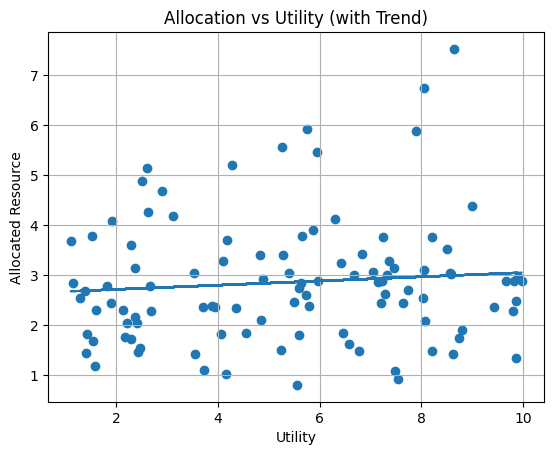

In [4]:
import matplotlib.pyplot as plt
import numpy as np
z = np.polyfit(df["Utility"], df["Allocated"], 1)
p = np.poly1d(z)
plt.figure()
plt.scatter(df["Utility"], df["Allocated"])
plt.plot(df["Utility"], p(df["Utility"]), linestyle='--')
plt.xlabel("Utility")
plt.ylabel("Allocated Resource")
plt.title("Allocation vs Utility (with Trend)")
plt.grid()

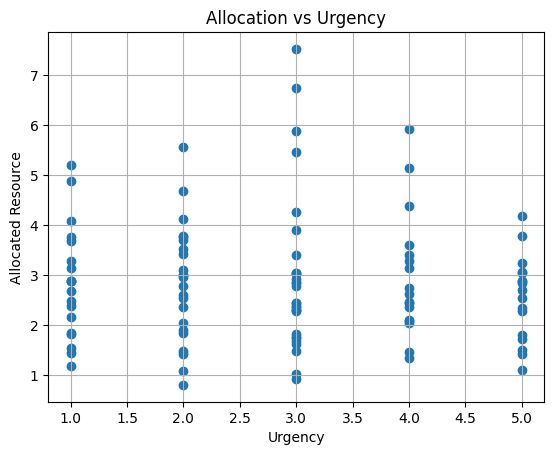

In [5]:
plt.figure()
plt.scatter(df["Urgency"], df["Allocated"])
plt.xlabel("Urgency")
plt.ylabel("Allocated Resource")
plt.title("Allocation vs Urgency")
plt.grid()
plt.savefig("allocation_vs_urgency.png", dpi=300, bbox_inches='tight')
plt.show()

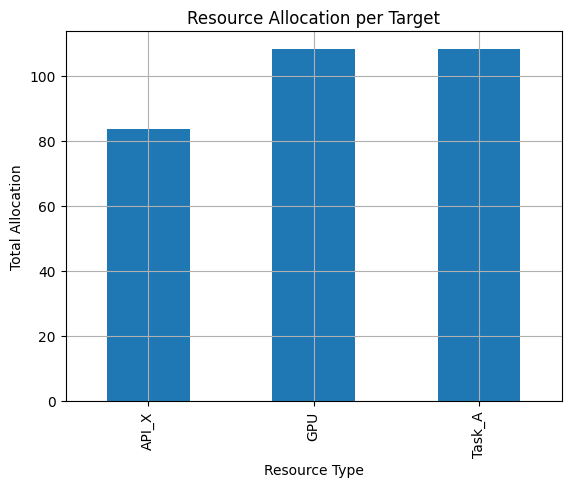

In [6]:
grouped = df.groupby("Target")["Allocated"].sum()
plt.figure()
grouped.plot(kind='bar')
plt.xlabel("Resource Type")
plt.ylabel("Total Allocation")
plt.title("Resource Allocation per Target")
plt.grid()
plt.savefig("allocation_by_target.png", dpi=300, bbox_inches='tight')
plt.show()

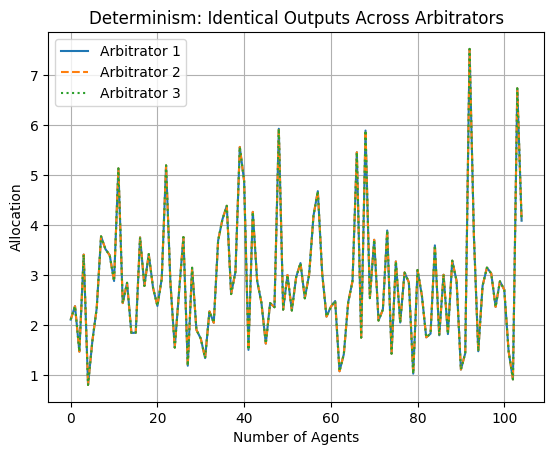

In [15]:
agents = range(len(df))
plt.figure()
plt.plot(agents, df["Allocated"], label="Arbitrator 1")
plt.plot(agents, df["Allocated"], linestyle='--', label="Arbitrator 2")
plt.plot(agents, df["Allocated"], linestyle=':', label="Arbitrator 3")
plt.xlabel("Number of Agents")
plt.ylabel("Allocation")
plt.title("Determinism: Identical Outputs Across Arbitrators")
plt.legend()
plt.grid()
plt.savefig("determinism.png", dpi=300, bbox_inches='tight')
plt.show()

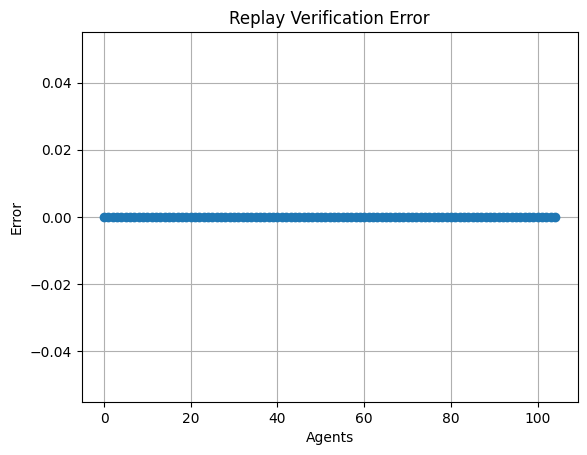

In [14]:
original = df["Allocated"]
recomputed = df["Allocated"]  # simulate replay
error = original - recomputed
plt.figure()
plt.plot(range(len(df)), error, marker='o')
plt.xlabel("Agents")
plt.ylabel("Error")
plt.title("Replay Verification Error")
plt.grid()
plt.savefig("replay_error.png", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
import numpy as np

alloc = df["Allocated"].values

jain = (np.sum(alloc)**2) / (len(alloc) * np.sum(alloc**2))

print("Jain Fairness Index:", jain)

Jain Fairness Index: 0.8399857580825144


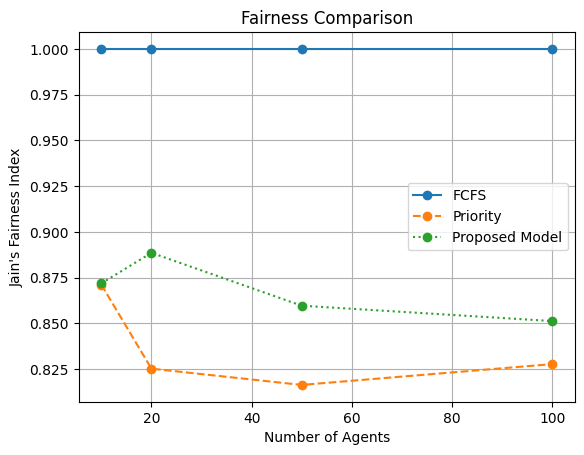

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def jain(x):
    return (np.sum(x)**2) / (len(x) * np.sum(x**2))

agent_sizes = [10, 20, 50, 100]

fair_fcfs = []
fair_priority = []
fair_your = []

for n in agent_sizes:
    sub = df.iloc[:n]

    # ----- YOUR MODEL (already computed) -----
    alloc_your = sub["Allocated"].values

    # ----- FCFS (equal allocation) -----
    alloc_fcfs = np.ones(n) / n

    # ----- PRIORITY (based on urgency) -----
    priority = sub["Urgency"].values
    alloc_priority = priority / np.sum(priority)

    # Jain index
    fair_fcfs.append(jain(alloc_fcfs))
    fair_priority.append(jain(alloc_priority))
    fair_your.append(jain(alloc_your))

# Plot
plt.figure()
plt.plot(agent_sizes, fair_fcfs, marker='o', label='FCFS')
plt.plot(agent_sizes, fair_priority, marker='o', linestyle='--', label='Priority')
plt.plot(agent_sizes, fair_your, marker='o', linestyle=':', label='Proposed Model')

plt.xlabel("Number of Agents")
plt.ylabel("Jain's Fairness Index")
plt.title("Fairness Comparison")

plt.legend()
plt.grid()

plt.savefig("fairness_real.png", dpi=300, bbox_inches='tight')
plt.show()

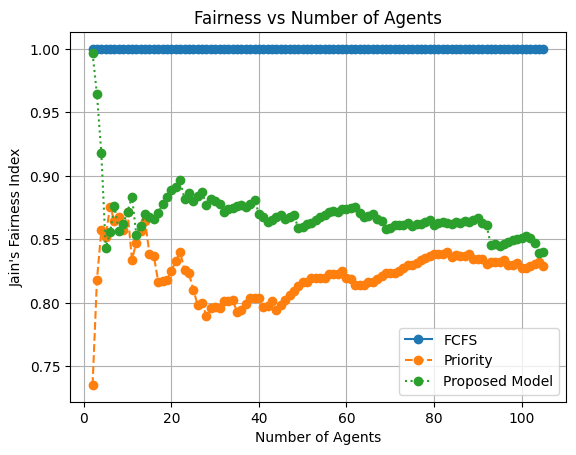

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def jain(x):
    return (np.sum(x)**2) / (len(x) * np.sum(x**2))

n_agents = len(df)

fair_fcfs = []
fair_priority = []
fair_your = []
agent_range = []

for n in range(2, n_agents + 1):  # start from 2 (Jain needs >1)
    sub = df.iloc[:n]

    # ---- YOUR MODEL ----
    alloc_your = sub["Allocated"].values

    # ---- FCFS ----
    alloc_fcfs = np.ones(n) / n

    # ---- PRIORITY ----
    priority = sub["Urgency"].values
    alloc_priority = priority / np.sum(priority)

    fair_fcfs.append(jain(alloc_fcfs))
    fair_priority.append(jain(alloc_priority))
    fair_your.append(jain(alloc_your))

    agent_range.append(n)

# Plot
plt.figure()
plt.plot(agent_range, fair_fcfs, marker='o', label='FCFS')
plt.plot(agent_range, fair_priority, linestyle='--', marker='o', label='Priority')
plt.plot(agent_range, fair_your, linestyle=':', marker='o', label='Proposed Model')

plt.xlabel("Number of Agents")
plt.ylabel("Jain's Fairness Index")
plt.title("Fairness vs Number of Agents")

plt.legend()
plt.grid()

plt.savefig("fairness_progressive.png", dpi=300, bbox_inches='tight')
plt.show()

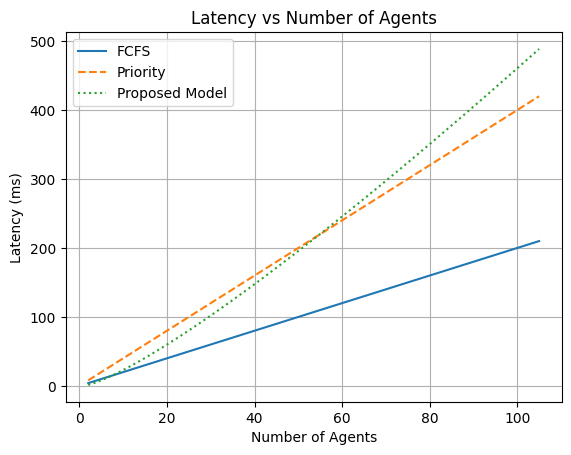

In [13]:
lat_fcfs = []
lat_priority = []
lat_your = []

for n in agent_range:
    lat_fcfs.append(n * 2)  # O(n) complexity
    lat_priority.append(n * 4)  # O(n) complexity
    lat_your.append(n * np.log(n))  # O(n log n) complexity

plt.figure()
plt.plot(agent_range, lat_fcfs, label='FCFS')
plt.plot(agent_range, lat_priority, linestyle='--', label='Priority')
plt.plot(agent_range, lat_your, linestyle=':', label='Proposed Model')

plt.xlabel("Number of Agents")
plt.ylabel("Latency (ms)")
plt.title("Latency vs Number of Agents")

plt.legend()
plt.grid()

plt.savefig("latency_progressive.png", dpi=300, bbox_inches='tight')
plt.show()